<a href="https://colab.research.google.com/github/prince969kr/sample_projec/blob/main/logistic_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

In [3]:
df = pd.read_csv("/content/logistics_delivery_delay_1000.csv")

df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Distance_km              1000 non-null   int64  
 1   Traffic_Level            1000 non-null   object 
 2   Weather                  1000 non-null   object 
 3   Road_Condition           1000 non-null   object 
 4   Route_Type               1000 non-null   object 
 5   Vehicle_Type             1000 non-null   object 
 6   Delivery_Priority        1000 non-null   object 
 7   Preparation_Time_min     1000 non-null   int64  
 8   Pickup_Delay_min         1000 non-null   int64  
 9   Driver_Experience_years  1000 non-null   float64
 10  Driver_Workload          1000 non-null   int64  
 11  Number_of_Stops          1000 non-null   int64  
 12  Package_Weight_kg        1000 non-null   float64
 13  Warehouse_Distance_km    1000 non-null   int64  
 14  Peak_Hour                

,Distance_km,Preparation_Time_min,Pickup_Delay_min,Driver_Experience_years,Driver_Workload,Number_of_Stops,Package_Weight_kg,Warehouse_Distance_km,Delivery_Delayed
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,39.80900,31.858000,14.735000,6.066600,5.479000,4.587000,15.725500,16.02500,0.824000
std,22.86962,15.988104,9.062058,3.273894,2.870505,2.344766,8.443758,8.70242,0.381011
min,2.00000,5.000000,0.000000,0.500000,1.000000,1.000000,0.600000,1.00000,0.000000
25%,20.00000,18.000000,7.000000,3.200000,3.000000,3.000000,8.600000,8.00000,1.000000
50%,39.00000,31.000000,15.000000,5.900000,6.000000,5.000000,16.000000,17.00000,1.000000
75%,60.00000,46.000000,22.000000,8.800000,8.000000,7.000000,23.100000,23.00000,1.000000
max,80.00000,60.000000,30.000000,12.000000,10.000000,8.000000,30.000000,30.00000,1.000000


In [4]:
df.isnull().sum()

,0
Distance_km,0
Traffic_Level,0
Weather,0
Road_Condition,0
Route_Type,0
Vehicle_Type,0
Delivery_Priority,0
Preparation_Time_min,0
Pickup_Delay_min,0
Driver_Experience_years,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["Delivery_Delayed"].value_counts()

,count
Delivery_Delayed,
1,824
0,176


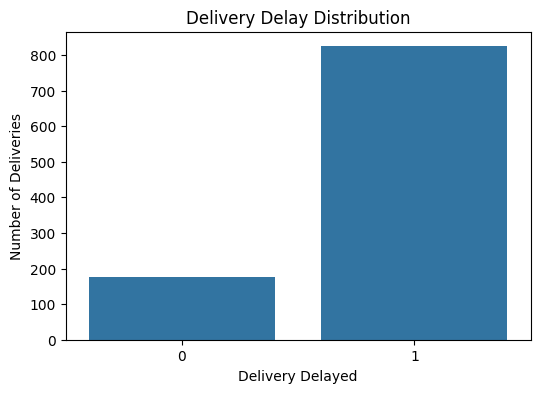

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Delivery_Delayed",
    data=df
)

plt.title("Delivery Delay Distribution")
plt.xlabel("Delivery Delayed")
plt.ylabel("Number of Deliveries")
plt.show()

In [8]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

numeric_cols

Index(['Distance_km', 'Preparation_Time_min', 'Pickup_Delay_min',
       'Driver_Experience_years', 'Driver_Workload', 'Number_of_Stops',
       'Package_Weight_kg', 'Warehouse_Distance_km', 'Delivery_Delayed'],
      dtype='object')

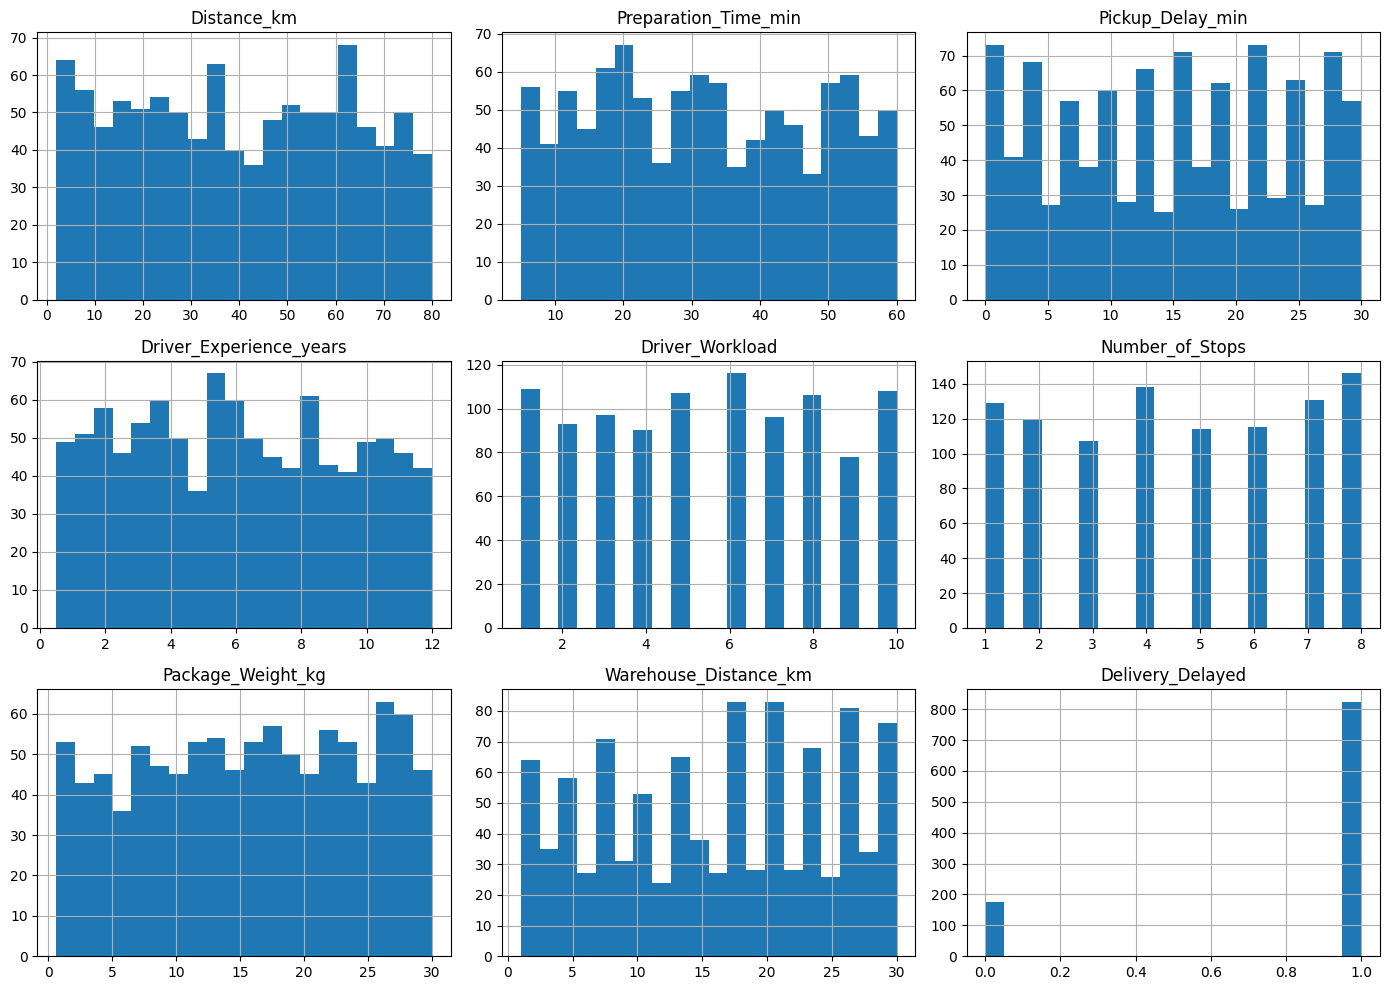

In [9]:
df[numeric_cols].hist(
    figsize=(14,10),
    bins=20
)

plt.tight_layout()
plt.show()

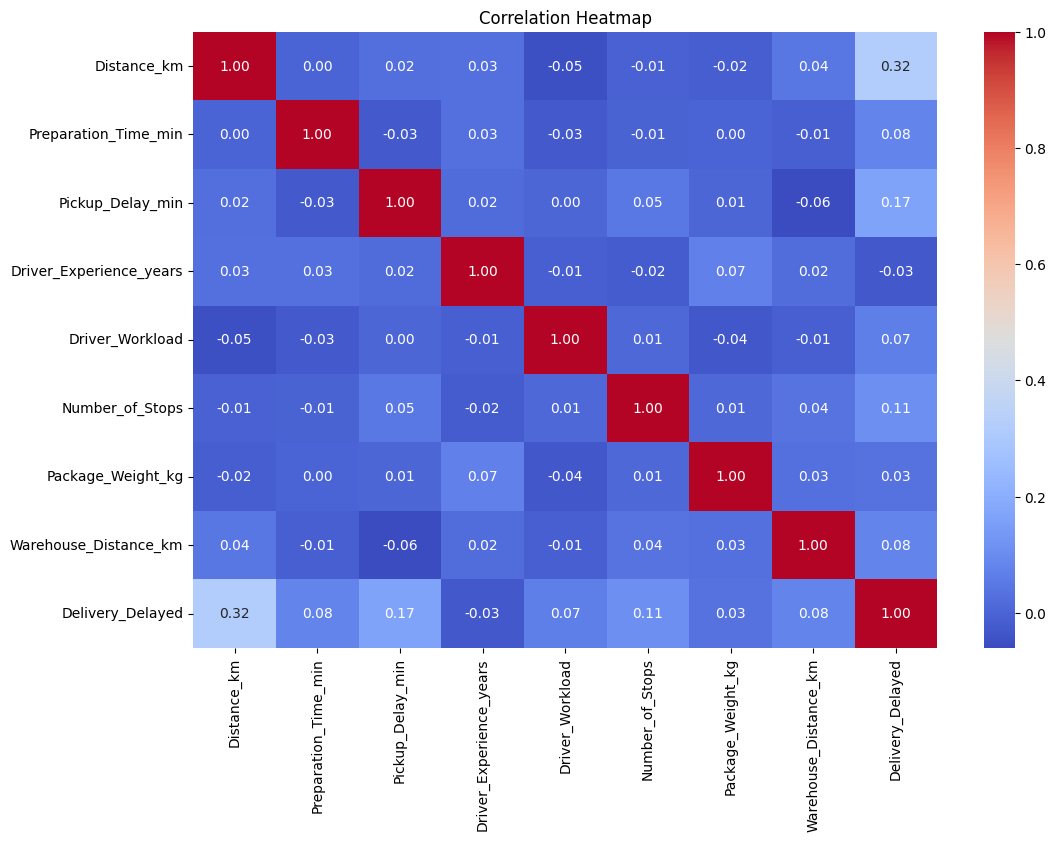

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

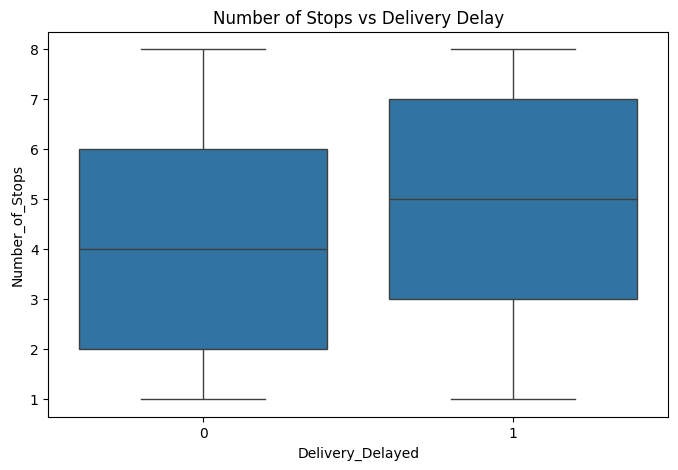

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Delivery_Delayed",
    y="Number_of_Stops",
    data=df
)

plt.title("Number of Stops vs Delivery Delay")
plt.show()

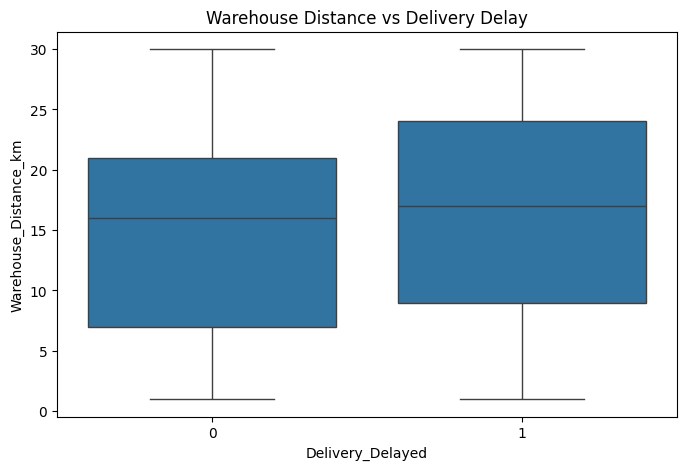

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Delivery_Delayed",
    y="Warehouse_Distance_km",
    data=df
)

plt.title("Warehouse Distance vs Delivery Delay")
plt.show()

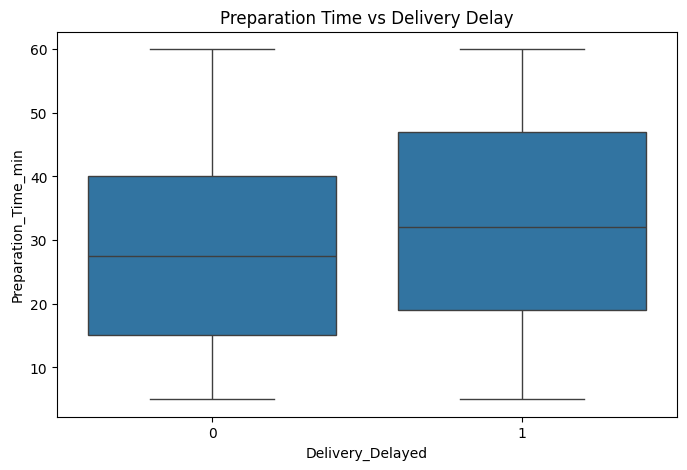

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Delivery_Delayed",
    y="Preparation_Time_min",
    data=df
)

plt.title("Preparation Time vs Delivery Delay")
plt.show()

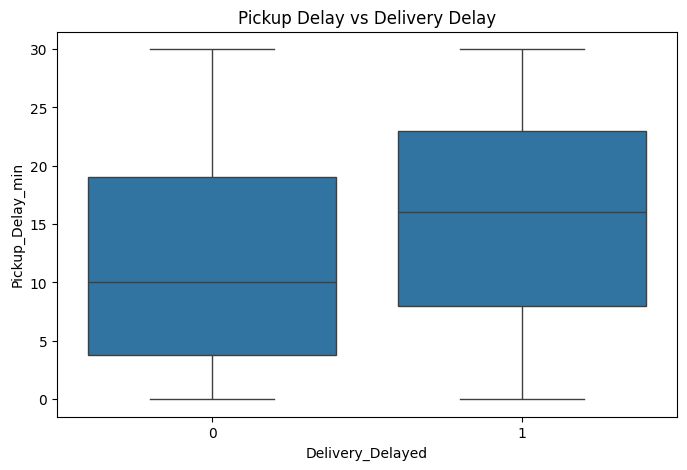

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Delivery_Delayed",
    y="Pickup_Delay_min",
    data=df
)

plt.title("Pickup Delay vs Delivery Delay")
plt.show()

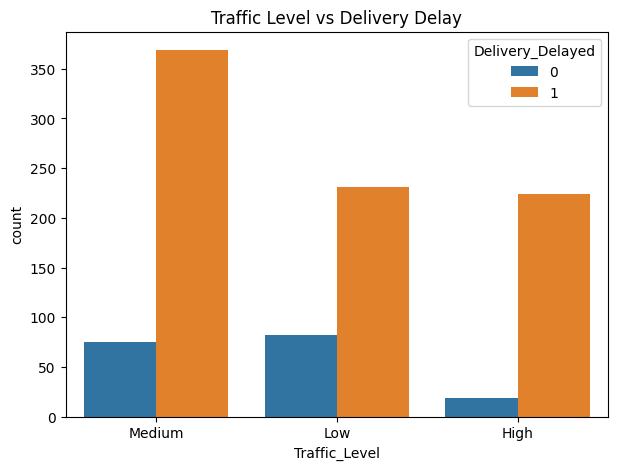

In [15]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Traffic_Level",
    hue="Delivery_Delayed",
    data=df
)

plt.title("Traffic Level vs Delivery Delay")
plt.show()

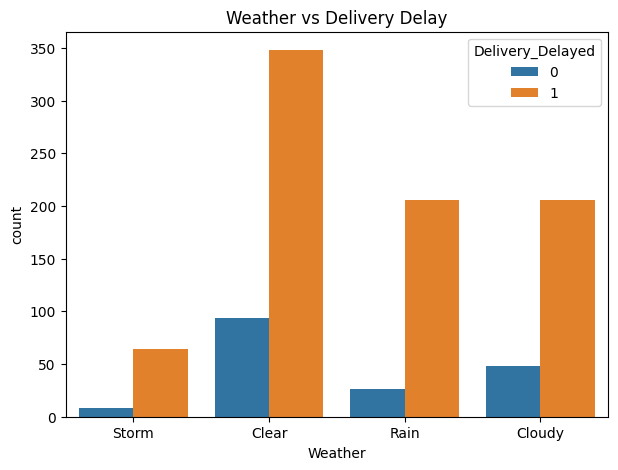

In [16]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Weather",
    hue="Delivery_Delayed",
    data=df
)

plt.title("Weather vs Delivery Delay")
plt.show()

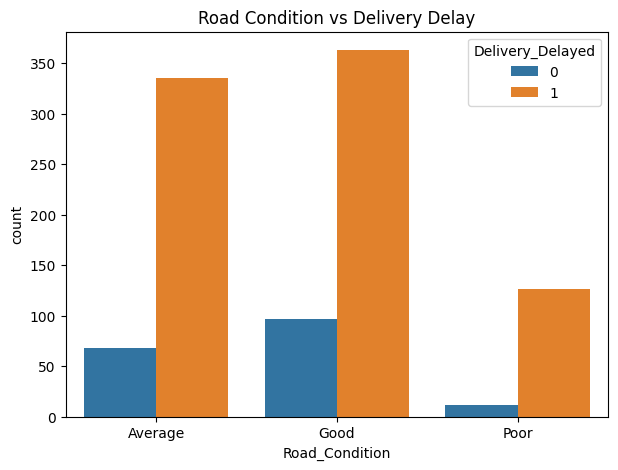

In [17]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Road_Condition",
    hue="Delivery_Delayed",
    data=df
)

plt.title("Road Condition vs Delivery Delay")
plt.show()

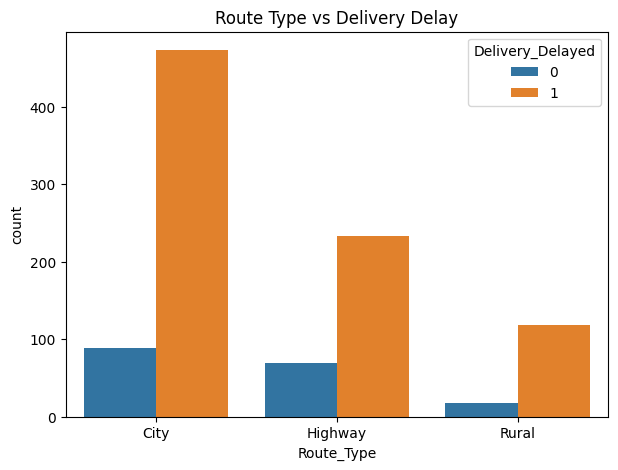

In [18]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Route_Type",
    hue="Delivery_Delayed",
    data=df
)

plt.title("Route Type vs Delivery Delay")
plt.show()

In [19]:
delay_rate = df["Delivery_Delayed"].mean() * 100

print("Delivery Delay Rate:",
      round(delay_rate, 2), "%")

Delivery Delay Rate: 82.4 %


In [20]:
on_time_rate = (1 - df["Delivery_Delayed"].mean()) * 100

print("On-Time Delivery Rate:",
      round(on_time_rate, 2), "%")

On-Time Delivery Rate: 17.6 %


In [21]:
print(
    "Average Pickup Delay:",
    round(df["Pickup_Delay_min"].mean(), 2),
    "minutes"
)

Average Pickup Delay: 14.74 minutes


In [ ]:
print(
    "Average Warehouse Distance:",
    round(df["Warehouse_Distance_km"].mean(), 2),
    "km"
)

In [22]:
print(
    "Average Number of Stops:",
    round(df["Number_of_Stops"].mean(), 2)
)

Average Number of Stops: 4.59


In [23]:
df.groupby("Delivery_Delayed")[
    "Number_of_Stops"
].mean()

,Number_of_Stops
Delivery_Delayed,
0,4.034091
1,4.705097


In [24]:
df.groupby("Delivery_Delayed")[
    "Warehouse_Distance_km"
].mean()

,Warehouse_Distance_km
Delivery_Delayed,
0,14.534091
1,16.343447


In [25]:
df.groupby("Delivery_Delayed")[
    "Pickup_Delay_min"
].mean()

,Pickup_Delay_min
Delivery_Delayed,
0,11.465909
1,15.433252


In [26]:
pd.crosstab(
    df["Traffic_Level"],
    df["Delivery_Delayed"],
    normalize="index"
) * 100

Delivery_Delayed,0,1
Traffic_Level,,
High,7.818930,92.181070
Low,26.198083,73.801917
Medium,16.891892,83.108108


In [27]:
pd.crosstab(
    df["Weather"],
    df["Delivery_Delayed"],
    normalize="index"
) * 100


Delivery_Delayed,0,1
Weather,,
Clear,21.266968,78.733032
Cloudy,18.897638,81.102362
Rain,11.206897,88.793103
Storm,11.111111,88.888889


In [28]:
x = df.iloc[:,[11,13]]
y = df.iloc[:,16]

In [29]:
X = df.drop("Delivery_Delayed", axis=1)

y = df["Delivery_Delayed"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 16)
Testing data: (200, 16)


In [31]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Traffic_Level', 'Weather', 'Road_Condition', 'Route_Type', 'Vehicle_Type', 'Delivery_Priority', 'Peak_Hour', 'Holiday']

Numerical Features:
['Distance_km', 'Preparation_Time_min', 'Pickup_Delay_min', 'Driver_Experience_years', 'Driver_Workload', 'Number_of_Stops', 'Package_Weight_kg', 'Warehouse_Distance_km']


In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [35]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

y_pred_lr = logistic_model.predict(X_test)

In [36]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.40      0.71      0.52        35
           1       0.93      0.78      0.84       165

    accuracy                           0.77       200
   macro avg       0.67      0.75      0.68       200
weighted avg       0.84      0.77      0.79       200



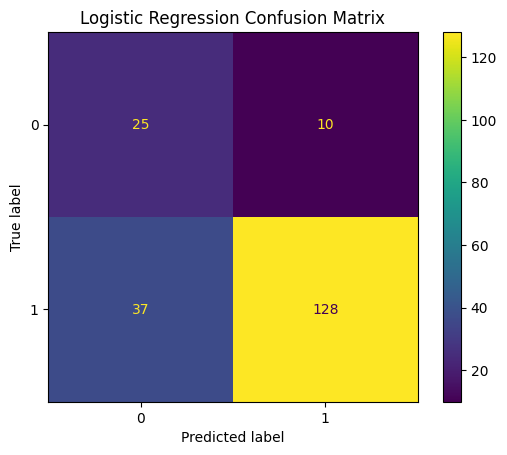

In [37]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

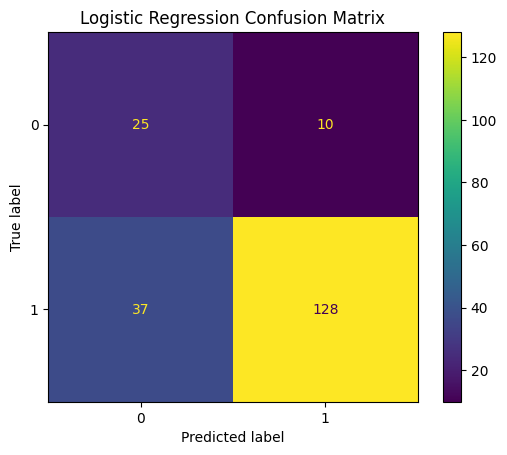

In [38]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [39]:
random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

random_forest.fit(
    X_train,
    y_train
)

y_pred_rf = random_forest.predict(X_test)

In [41]:
knn = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "model",
            KNeighborsClassifier(
                n_neighbors=7
            )
        )
    ]
)

knn.fit(
    X_train,
    y_train
)

y_pred_knn = knn.predict(X_test)

In [43]:
models = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn
}

results = []

for name, predictions in models.items():

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.765,0.927536,0.775758,0.844884
1,Random Forest,0.830,0.850267,0.963636,0.903409
2,KNN,0.820,0.848649,0.951515,0.897143
